In [20]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from utils import generate_laplacian, get_circuit_unitary
from foqcs_lcu.foqcs_lcu import select_foqcs_lcu, sub_prep_foqcs_lcu

from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliGate

from qiskit import transpile
from qiskit_aer import AerSimulator

In [21]:
def PauliDecomposition(matrix, sparse=False, PauliStringInit="", output="Lists", tolerance=1e-6):
    """
        Computes the Pauli decomposition of a square matrix.

        Iteratively splits tensor factors off and decomposes those smaller
        matrices. This is done using submatrices of the original matrix.
        The Pauli strings are generated in each step.

        Args:
            matrix: Matrix to be decomposed
                    (Preferably numpy array/scipysparse).
            output: How the output should be generated.
            sparse: Whether matrix is in sparse format.
            PauliStringInit: For recursive computation.
            tolerance: Threshold below which coefficients are ignored.

        Returns:
            decomposition/outString: String of 1XYZ with their factors.
    """
    matDim = matrix.shape[0]
    qBitDim = math.ceil(np.log(matDim) / np.log(2))

    # Pad, if dimension is not a power of 2
    padDim = 2**qBitDim - matDim
    if padDim != 0:  # This condition states that the padding happens only if needed
        if sparse:
            indxptr = np.pad(matrix.indptr, ((0, padDim), (0, padDim)))
            matrix = csr_matrix((matrix.data, matrix.indices, indxptr))
        else:
            matrix = np.pad(matrix, ((0, padDim), (0, padDim)))

    decomposition = []

    if output == "Lists":
        Strings = []
        Coeffs = []

    # Output for dimension 1
    if qBitDim == 0:
        if abs(matrix[0, 0]) > tolerance:  # Ignore small coefficients
            if output == "Lists":
                Strings.append(PauliStringInit)
                try:
                    Coeffs.append(matrix[0, 0])
                except:
                    Coeffs.append(matrix[0, 0].numpy())
            else:
                decomposition = [f"{matrix[0, 0]}, {PauliStringInit}. "]

    # Calculates the tensor product coefficients via the sliced submatrices.
    if qBitDim > 0:
        halfDim = int(2**(qBitDim - 1))

        coeff1 = 0.5 * (matrix[0:halfDim, 0:halfDim] + matrix[halfDim:, halfDim:])
        coeffX = 0.5 * (matrix[halfDim:, 0:halfDim] + matrix[0:halfDim, halfDim:])
        coeffY = -1.j * 0.5 * (matrix[halfDim:, 0:halfDim] - matrix[0:halfDim, halfDim:])
        coeffZ = 0.5 * (matrix[0:halfDim, 0:halfDim] - matrix[halfDim:, halfDim:])

        coefficients = {"I": coeff1, "X": coeffX, "Y": coeffY, "Z": coeffZ}

        matrix = None

        # Recursion for the submatrices
        for c in coefficients:
            mat = coefficients[c]
            if sparse:
                nonZero = len(mat.nonzero()[0])
            else:
                nonZero = np.any(np.abs(mat) > tolerance)  # Check for significant values
            
            # Ignore zero or near-zero matrices
            if nonZero:
                subDec = PauliDecomposition(
                    mat, sparse, f"{PauliStringInit}{c}", output, tolerance
                )
                if output == "Lists":
                    Strings.extend(subDec[0])
                    Coeffs.extend(subDec[1])
                else:
                    decomposition.append(subDec)

    if output == "Lists":
        return [Strings, Coeffs]
    else:
        outputString = "".join(decomposition)
        return outputString

# Check-matrix mapping: Pauli decomposition &rarr; subPREP coefficients

`PauliDecomposition` returns Pauli strings/coefficients in whatever order its recursion
happened to find them. `select_foqcs_lcu`/`sub_prep_foqcs_lcu` do **not** consume that
order directly: per Eq. (17)-(21) of the paper, each Pauli string must first be mapped to
a combined `(i, j)` index pair via the check-matrix formalism of Table I
(`I->(0,0)`, `Z->(0,1)`, `X->(1,0)`, `Y->(1,1)`), the coefficient must absorb the phase
`(-i)^(sum_l i_l * j_l)`, and the result placed at flat index `i + 2**n * j` (ancilla
qubits `[0, n)` are the i-register that drives the SELECT CNOTs, ancilla qubits `[n, 2n)`
are the j-register that drives the SELECT CZs). 

In [22]:

_CHECK_MATRIX = {"I": (0, 0), "Z": (0, 1), "X": (1, 0), "Y": (1, 1)}


def pauli_string_to_ij(pauli_string):
    """Maps a Pauli string to the combined (i, j) indices of Eq. (18)."""
    n = len(pauli_string)
    i_int = j_int = 0
    for pos, ch in enumerate(pauli_string):
        qubit = n - 1 - pos
        i_bit, j_bit = _CHECK_MATRIX[ch]
        i_int |= i_bit << qubit
        j_int |= j_bit << qubit
    return i_int, j_int


def pauli_decomposition_to_prep_coeffs(ops, coefs, n):
    """Builds the length-4**n check-matrix-ordered coefficient array required by
    sub_prep_foqcs_lcu, following Eq. (19)-(21)
    """
    prep_coeffs = np.zeros(4**n, dtype=complex)
    for op, alpha in zip(ops, coefs):
        i_int, j_int = pauli_string_to_ij(op)
        phase = (-1j) ** bin(i_int & j_int).count("1")
        prep_coeffs[i_int + (2**n) * j_int] = phase * alpha
    return prep_coeffs

# Test for a Dirichlet Laplacian

Matrix size 4x4

In [23]:
mat = generate_laplacian([4], analytic_normalize=True).todense()
ops, coefs = PauliDecomposition(mat)
n_sys = len(ops[0])  # number of system qubits = length of each Pauli string
print(list(zip(ops, coefs)))

# Map the raw Pauli decomposition onto the check-matrix-ordered coefficients that
# sub_prep_foqcs_lcu / select_foqcs_lcu actually expect 
coefs = pauli_decomposition_to_prep_coeffs(ops, coefs, n_sys)
coefs = np.sqrt(coefs)

[('II', np.float64(-0.5)), ('IX', np.float64(0.25)), ('XX', np.float64(0.125)), ('YY', np.complex128(0.125+0j))]


In [24]:
L = n_sys
subprep = sub_prep_foqcs_lcu(coefs, normalization=True, compact=True)
subprepL = sub_prep_foqcs_lcu(coefs.conj(), normalization=True, compact=True)
select = select_foqcs_lcu(L)

qc = QuantumCircuit(3 * L)
qc.append(subprep, list(range(0, 2*L)))
qc.append(select, list(range(3 * L)))
qc.append(subprepL.inverse(), list(range(0, 2*L)))
op = qc.to_instruction()
qc.draw()

┌──────────┐┌─────────┐┌─────────────────┐
q_0: ┤0         ├┤0        ├┤0                ├
     │          ││         ││                 │
q_1: ┤1         ├┤1        ├┤1                ├
     │  subPREP ││         ││  circuit-207_dg │
q_2: ┤2         ├┤2        ├┤2                ├
     │          ││  SELECT ││                 │
q_3: ┤3         ├┤3        ├┤3                ├
     └──────────┘│         │└─────────────────┘
q_4: ────────────┤4        ├───────────────────
                 │         │                   
q_5: ────────────┤5        ├───────────────────
                 └─────────┘

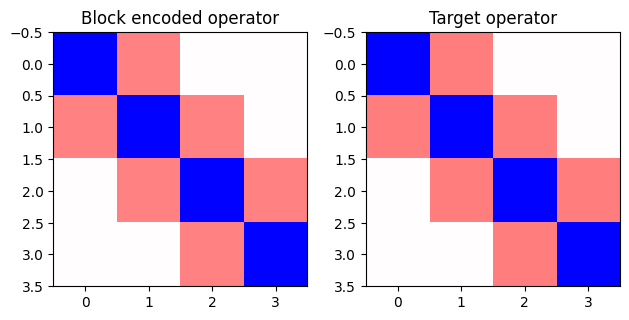

In [25]:
qc2 = QuantumCircuit(3 * L)
qc2.append(op, [4, 5, 2, 3, 0, 1])
qc2.decompose().draw()

fig, axs = plt.subplots(1, 2)
axs[0].imshow(get_circuit_unitary(qc2, [2]), cmap="seismic", vmin=-1, vmax=1)
axs[0].set_title("Block encoded operator")

axs[1].imshow(generate_laplacian([4], analytic_normalize=True).todense(), cmap="seismic", vmin=-1, vmax=1)
axs[1].set_title("Target operator")

fig.tight_layout()
plt.show()

In [26]:

block = get_circuit_unitary(qc2, [2])
target = generate_laplacian([4], analytic_normalize=True).todense()

np.testing.assert_allclose(block, target, atol=1e-8)
print(
    "PASS: FOQCS-LCU block encoding matches the Dirichlet Laplacian "
    f"(max abs diff = {np.max(np.abs(block - target)):.2e})."
)

PASS: FOQCS-LCU block encoding matches the Dirichlet Laplacian (max abs diff = 1.64e-15).


# FOQCS-LCU $X \otimes X$ operator block encoding test

In [27]:
# Matrix definitions used to verify block encodings
eye = np.eye(2)
x = np.array([[0, 1], [1, 0]])
y = np.array([[0, -1j], [1j, 0]])
z = np.array([[1, 0], [0, -1]])

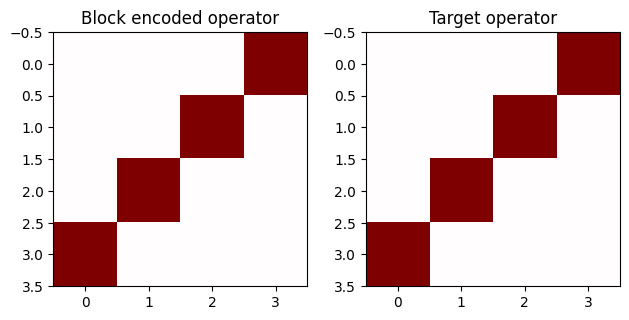

PASS: FOQCS-LCU block encoding matches X (x) X (max abs diff = 4.88e-15).


In [ ]:
n_sys = 2
target_pauli = "XX"

# Build the check-matrix coefficients for a single target Pauli string directly
i_target, j_target = pauli_string_to_ij(target_pauli)
coefs = np.zeros(4**n_sys, dtype=complex)
coefs[i_target + 2**n_sys * j_target] = 1.0
coefs = np.sqrt(coefs)

# Prepare circuit
L = n_sys
subprep = sub_prep_foqcs_lcu(coefs, normalization=True, compact=True)
subprepL = sub_prep_foqcs_lcu(coefs.conj(), normalization=True, compact=True)
select = select_foqcs_lcu(L)

qc = QuantumCircuit(3 * L)
qc.append(subprep, list(range(0, 2 * L)))
qc.append(select, list(range(3 * L)))
qc.append(subprepL.inverse(), list(range(0, 2 * L)))
op = qc.to_instruction()
qc.draw()

qc2 = QuantumCircuit(3 * L)
qc2.append(op, [4, 5, 2, 3, 0, 1])
qc2.decompose().draw()

# Plot and compare between simulation and expected results
fig, axs = plt.subplots(1, 2)
axs[0].imshow(get_circuit_unitary(qc2, [2]), cmap="seismic", vmin=-1, vmax=1)
axs[0].set_title("Block encoded operator")

axs[1].imshow(np.kron(x, x), cmap="seismic", vmin=-1, vmax=1)
axs[1].set_title("Target operator")

fig.tight_layout()
plt.show()

# --- test ---
block = get_circuit_unitary(qc2, [2])
target = np.kron(x, x)
np.testing.assert_allclose(block, target, atol=1e-8)
print(
    "PASS: FOQCS-LCU block encoding matches X (x) X "
    f"(max abs diff = {np.max(np.abs(block - target)):.2e})."
)